# Step 4: Active Learning パイプライン（論文風）

Step 1〜3 の全技術を統合して、論文のワークフローを再現する。

**論文のパイプライン:**
```
初期データ → DKL サロゲート × 2目的 → qNEHVI で候補選択
→ 評価（=MDシミュレーション）→ モデル更新 → ALループ
→ パレートフロント上の候補を特定 → 解釈性分析
```

**このノートブックでは:**
- 公開ポリマーDBの代わりに、論文の設定を模した**合成ポリマーデータ**を使う
  - 50次元の分子記述子（高次元 → DKL の出番）
  - 2つの物性値（熱伝導率 TC, 柔軟性 = 1/弾性率）
  - 500個のポリマー候補プール
- 初期データ20個 → AL で30ラウンド → パレートフロント可視化
- 特徴量重要度の分析（どの記述子が物性に効いているか）

**構成:**
1. 合成ポリマーデータの生成
2. AL パイプラインの実装
3. パレートフロントの成長の可視化
4. 解釈性分析

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import gpytorch
from gpytorch.models import ExactGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.gpytorch import GPyTorchModel
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement
from botorch.optim import optimize_acqf
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.hypervolume import Hypervolume
from botorch.models.model import ModelList

dtype = torch.double
torch.manual_seed(42)
%matplotlib inline

## 1. 合成ポリマーデータの生成

論文の状況を模倣:
- 500個のポリマー候補（= MDで評価可能な候補プール）
- 各ポリマーは50次元の分子記述子で表現
- 物性に本当に効くのは一部の記述子だけ（残りはノイズ）
- 2つの物性値はトレードオフ関係（TC↑ → 弾性率↑ = 柔軟性↓）

実務では「候補プール全部を評価するのはコストが高い → ALで効率的に評価する」という流れ。

ポリマー候補プール:
  候補数: 2000
  記述子次元: 50
  有効記述子: [0, 1, 2, 3, 4] (5個/50個)
  TC 範囲:   [-1.99, 3.68]
  柔軟性範囲: [-1.95, 2.50]


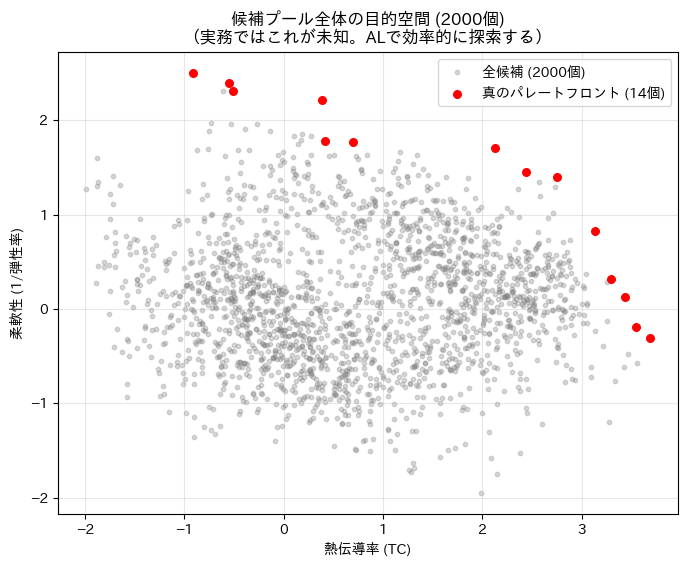


候補プールの 2.5% (50個) だけ評価してパレートフロントを見つけたい


In [10]:
def generate_polymer_data(n_polymers=2000, n_descriptors=50, n_effective=5, seed=42):
    """論文を模した合成ポリマーデータを生成

    Args:
        n_polymers: 候補ポリマー数
        n_descriptors: 分子記述子の次元数
        n_effective: 実際に物性に効く記述子の数
        seed: 乱数シード

    Returns:
        X: 分子記述子 (n_polymers, n_descriptors)
        Y_tc: 熱伝導率 (n_polymers,)
        Y_flex: 柔軟性 (n_polymers,)
        effective_dims: 有効な記述子のインデックス
    """
    torch.manual_seed(seed)

    X = torch.rand(n_polymers, n_descriptors, dtype=dtype)
    effective_dims = list(range(n_effective))
    x_eff = X[:, effective_dims]

    # 熱伝導率 (TC): 記述子間の交互作用を含む複雑な関数
    Y_tc = (
        2.0 * torch.sin(5 * x_eff[:, 0]) * torch.exp(-x_eff[:, 1])
        + 1.5 * (x_eff[:, 2] * x_eff[:, 3]).pow(2)
        + 1.0 * torch.cos(4 * x_eff[:, 1] * x_eff[:, 4])
        + 0.05 * torch.randn(n_polymers, dtype=dtype)
    )

    # 柔軟性: TC と強いトレードオフ（高TC領域で柔軟性が急激に下がる）
    Y_flex = (
        2.0 * torch.cos(5 * x_eff[:, 0]) * (1 - torch.exp(-x_eff[:, 1]))
        + 1.5 * x_eff[:, 3] * x_eff[:, 4]
        - 1.5 * (x_eff[:, 2] * x_eff[:, 3]).pow(2)  # TC と逆方向
        + 0.3 * torch.sin(8 * x_eff[:, 2])
        + 0.05 * torch.randn(n_polymers, dtype=dtype)
    )

    return X, Y_tc, Y_flex, effective_dims


X_pool, Y_tc_pool, Y_flex_pool, effective_dims = generate_polymer_data()
Y_pool = torch.stack([Y_tc_pool, Y_flex_pool], dim=-1)

print(f"ポリマー候補プール:")
print(f"  候補数: {len(X_pool)}")
print(f"  記述子次元: {X_pool.shape[1]}")
print(f"  有効記述子: {effective_dims} (5個/50個)")
print(f"  TC 範囲:   [{Y_tc_pool.min():.2f}, {Y_tc_pool.max():.2f}]")
print(f"  柔軟性範囲: [{Y_flex_pool.min():.2f}, {Y_flex_pool.max():.2f}]")

pareto_all = is_non_dominated(Y_pool)
plt.figure(figsize=(8, 6))
plt.scatter(Y_pool[~pareto_all, 0], Y_pool[~pareto_all, 1],
            c="gray", alpha=0.3, s=10, label=f"全候補 ({len(X_pool)}個)")
plt.scatter(Y_pool[pareto_all, 0], Y_pool[pareto_all, 1],
            c="red", s=30, label=f"真のパレートフロント ({pareto_all.sum()}個)")
plt.xlabel("熱伝導率 (TC)")
plt.ylabel("柔軟性 (1/弾性率)")
plt.title("候補プール全体の目的空間 (2000個)\n（実務ではこれが未知。ALで効率的に探索する）")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"\n候補プールの {50/len(X_pool)*100:.1f}% (50個) だけ評価してパレートフロントを見つけたい")

In [17]:
X_pool.shape

torch.Size([2000, 50])

## 2. AL パイプラインの実装

論文と同じ流れ:
1. 初期データ（ランダムに20個を「実験済み」とする）
2. DKL × 2目的 を学習
3. qLogNEHVI で「次に実験すべきポリマー」を候補プールから選択
4. 評価結果を追加 → 2に戻る

Step 1〜3 との違い: **連続空間の最適化ではなく、離散的な候補プールから選ぶ**。
実務では「合成可能なポリマーの候補リスト」が決まっているため、その中から選ぶ。

In [11]:
# Step 3 の DKL モデル定義を再利用
class FeatureExtractor(nn.Sequential):
    def __init__(self, input_dim, hidden_dim=64, output_dim=8):
        super().__init__(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

class DKLModel(ExactGP, GPyTorchModel):
    _num_outputs = 1

    def __init__(self, train_x, train_y, likelihood, feature_extractor):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        feature_dim = feature_extractor[-1].out_features
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=feature_dim)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        mean = self.mean_module(features)
        covar = self.covar_module(features)
        return gpytorch.distributions.MultivariateNormal(mean, covar)

def create_and_train_dkl(train_x, train_y, input_dim, hidden_dim=64,
                          feature_dim=8, n_epochs=200, lr=0.01):
    """DKL モデルを作成・学習して返す"""
    fe = FeatureExtractor(input_dim, hidden_dim, feature_dim).to(dtype=dtype)
    lik = gpytorch.likelihoods.GaussianLikelihood().to(dtype=dtype)
    model = DKLModel(train_x, train_y, lik, fe).to(dtype=dtype)

    model.train()
    lik.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = ExactMarginalLogLikelihood(lik, model)

    for _ in range(n_epochs):
        optimizer.zero_grad()
        loss = -mll(model(train_x), train_y)
        loss.backward()
        optimizer.step()

    model.eval()
    lik.eval()
    return model

print("DKL モデル定義完了（Step 3 と同じ）")

DKL モデル定義完了（Step 3 と同じ）


In [12]:
def run_al_pipeline(X_pool, Y_pool, n_initial=20, n_rounds=30, seed=0):
    """Active Learning パイプライン（離散候補プールから選択）

    論文の流れを再現:
    - 初期データをランダムに選ぶ
    - 各ラウンドで DKL を学習し、qLogNEHVI で次の候補を選ぶ
    - 候補プールから1つずつ「実験」していく
    """
    torch.manual_seed(seed)
    n_pool, input_dim = X_pool.shape

    # 初期データ: ランダムに n_initial 個を選択
    all_indices = torch.randperm(n_pool)
    observed_idx = all_indices[:n_initial].tolist()
    remaining_idx = all_indices[n_initial:].tolist()

    ref_point = Y_pool.min(dim=0).values - 0.1
    hv = Hypervolume(ref_point=ref_point)
    history = []

    # 初期状態の記録
    Y_observed = Y_pool[observed_idx]
    pareto_mask = is_non_dominated(Y_observed)
    history.append({
        "round": 0,
        "hv": hv.compute(Y_observed[pareto_mask]),
        "n_pareto": pareto_mask.sum().item(),
        "n_observed": len(observed_idx),
        "observed_idx": list(observed_idx),
    })
    print(f"  初期: {n_initial}個, PF={pareto_mask.sum().item()}個, HV={history[-1]['hv']:.4f}")

    for r in range(n_rounds):
        X_obs = X_pool[observed_idx]
        Y_obs = Y_pool[observed_idx]

        # 目的ごとに DKL を学習
        models = []
        for obj_idx in range(2):
            model = create_and_train_dkl(
                X_obs, Y_obs[:, obj_idx], input_dim=input_dim,
                hidden_dim=64, feature_dim=8, n_epochs=200, lr=0.01,
            )
            models.append(model)
        model_list = ModelList(*models)

        # 未観測の候補に対して獲得関数を評価
        X_remaining = X_pool[remaining_idx]
        acqf = qLogNoisyExpectedHypervolumeImprovement(
            model=model_list,
            ref_point=ref_point.tolist(),
            X_baseline=X_obs,
        )

        # 候補プールから最良の1点を選ぶ（離散最適化）
        with torch.no_grad():
            acq_values = acqf(X_remaining.unsqueeze(1))  # (n_remaining, 1, d)
        best_local_idx = acq_values.argmax().item()
        best_pool_idx = remaining_idx[best_local_idx]

        # 「実験」して結果を追加
        observed_idx.append(best_pool_idx)
        remaining_idx.pop(best_local_idx)

        # 記録
        Y_observed = Y_pool[observed_idx]
        pareto_mask = is_non_dominated(Y_observed)
        current_hv = hv.compute(Y_observed[pareto_mask])
        history.append({
            "round": r + 1,
            "hv": current_hv,
            "n_pareto": pareto_mask.sum().item(),
            "n_observed": len(observed_idx),
            "observed_idx": list(observed_idx),
            "selected_idx": best_pool_idx,
            "models": models,  # 最後のモデルを解釈性分析用に保存
        })

        if (r + 1) % 5 == 0:
            print(f"  Round {r+1:2d}: 観測={len(observed_idx)}個, "
                  f"PF={pareto_mask.sum().item()}個, HV={current_hv:.4f}")

    return history

print("AL パイプライン開始 (30 rounds)...")
print("（各ラウンドで DKL×2 を学習するため数分かかります）\n")
history_al = run_al_pipeline(X_pool, Y_pool)

print(f"\n最終結果:")
print(f"  観測数: {history_al[-1]['n_observed']} / {len(X_pool)}")
print(f"  パレート最適: {history_al[-1]['n_pareto']}個")
print(f"  超体積: {history_al[-1]['hv']:.4f}")

AL パイプライン開始 (30 rounds)...
（各ラウンドで DKL×2 を学習するため数分かかります）

  初期: 20個, PF=4個, HV=14.1537
  Round  5: 観測=25個, PF=7個, HV=14.6276
  Round 10: 観測=30個, PF=8個, HV=14.8163
  Round 15: 観測=35個, PF=8個, HV=15.5699
  Round 20: 観測=40個, PF=6個, HV=18.1309
  Round 25: 観測=45個, PF=7個, HV=18.3181
  Round 30: 観測=50個, PF=6個, HV=19.2564

最終結果:
  観測数: 50 / 2000
  パレート最適: 6個
  超体積: 19.2564


## 3. パレートフロントの成長を可視化

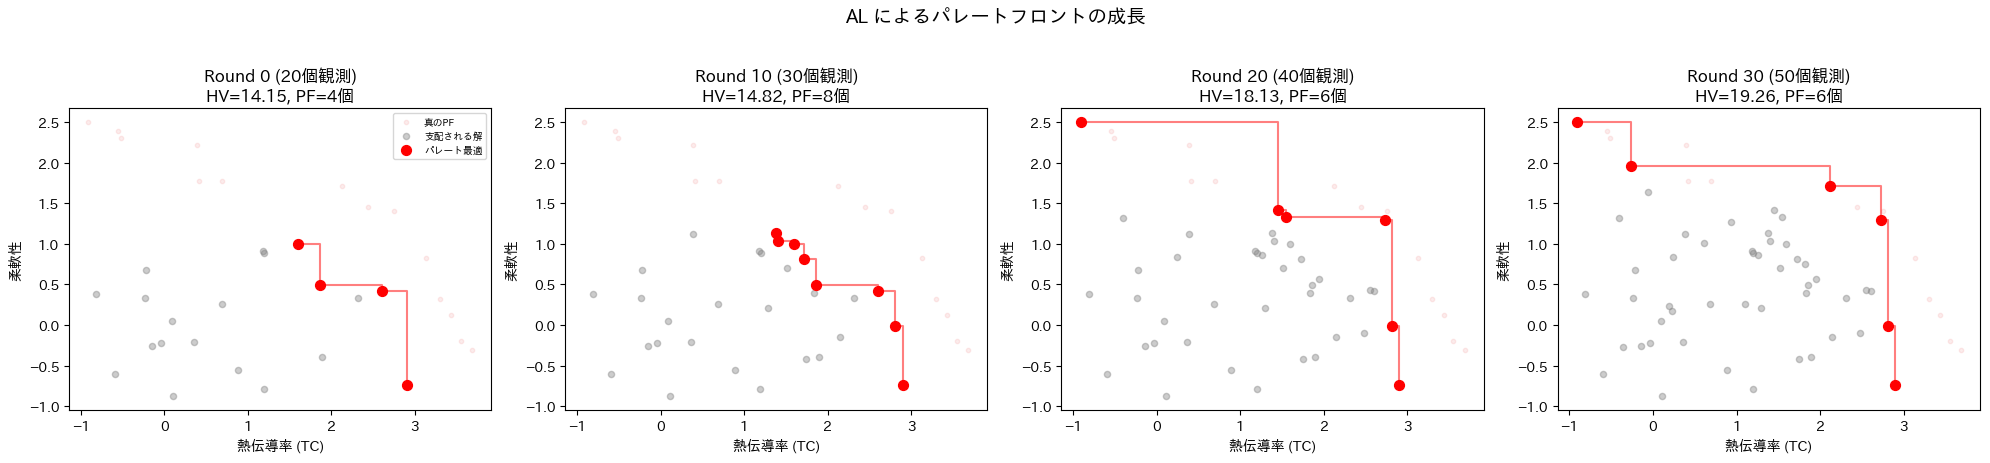

In [13]:
# パレートフロントの成長スナップショット
snapshots = [0, 10, 20, 30]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, snap_round in zip(axes, snapshots):
    h = history_al[snap_round]
    Y_obs = Y_pool[h["observed_idx"]]
    pareto_mask = is_non_dominated(Y_obs)

    # 真のパレートフロント（参考）
    ax.scatter(Y_pool[pareto_all, 0], Y_pool[pareto_all, 1],
               c="lightcoral", alpha=0.15, s=10, label="真のPF")

    ax.scatter(Y_obs[~pareto_mask, 0], Y_obs[~pareto_mask, 1],
               c="gray", alpha=0.4, s=20, label="支配される解")
    ax.scatter(Y_obs[pareto_mask, 0], Y_obs[pareto_mask, 1],
               c="red", s=50, zorder=5, label="パレート最適")

    pf = Y_obs[pareto_mask].numpy()
    pf = pf[pf[:, 0].argsort()]
    ax.step(pf[:, 0], pf[:, 1], "r-", where="post", alpha=0.5)

    ax.set_xlabel("熱伝導率 (TC)")
    ax.set_ylabel("柔軟性")
    ax.set_title(f"Round {snap_round} ({h['n_observed']}個観測)\nHV={h['hv']:.2f}, PF={h['n_pareto']}個")
    if snap_round == 0:
        ax.legend(fontsize=7)

plt.suptitle("AL によるパレートフロントの成長", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

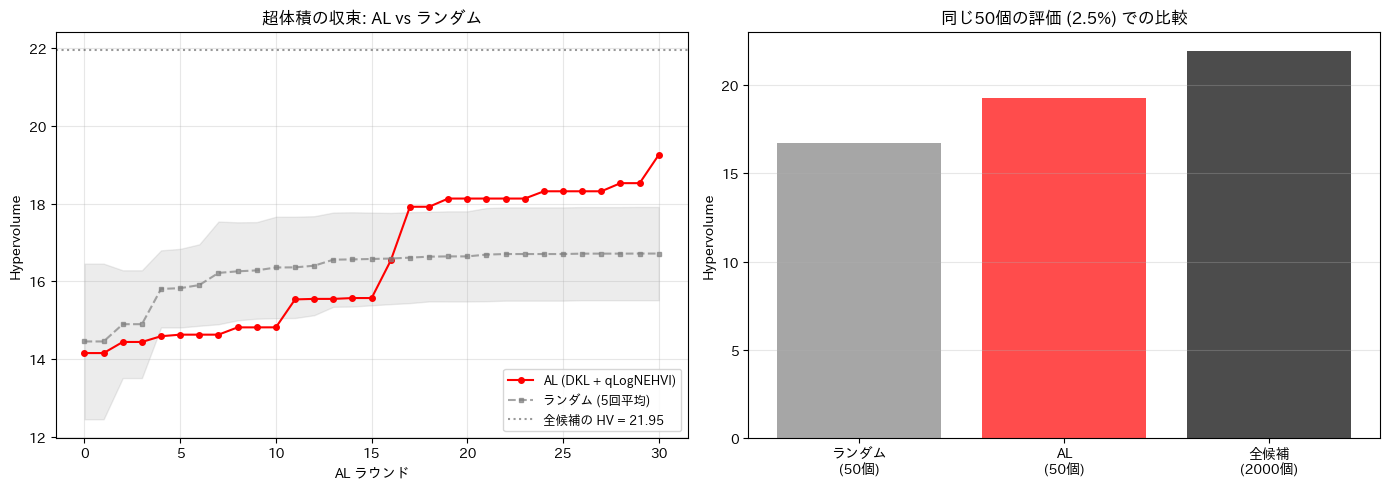

50個の評価での超体積:
  ランダム (平均): 16.71 ± 1.20
  AL:              19.26
  全候補:          21.95 (上限)

→ AL は 2000個中50個 (2.5%) の評価で探索


In [14]:
# 超体積の収束 + ランダムサーチとの比較（複数シードで平均）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AL の超体積
hvs_al = [h["hv"] for h in history_al]
rounds = [h["round"] for h in history_al]
ax1.plot(rounds, hvs_al, "o-", color="red", markersize=4, label="AL (DKL + qLogNEHVI)")

# ランダムサーチ: 5回の平均 ± 標準偏差
ref_point = Y_pool.min(dim=0).values - 0.1
hv = Hypervolume(ref_point=ref_point)
n_random_trials = 5
all_hvs_random = []
for trial in range(n_random_trials):
    torch.manual_seed(trial * 100 + 99)
    rand_indices = torch.randperm(len(X_pool))
    hvs_one = []
    for n_obs in range(20, 51):
        Y_rand = Y_pool[rand_indices[:n_obs]]
        pm = is_non_dominated(Y_rand)
        hvs_one.append(hv.compute(Y_rand[pm]))
    all_hvs_random.append(hvs_one)

hvs_random_mean = np.mean(all_hvs_random, axis=0)
hvs_random_std = np.std(all_hvs_random, axis=0)
x_rounds = list(range(0, 31))
ax1.plot(x_rounds, hvs_random_mean, "s--", color="gray", markersize=3, alpha=0.7, label="ランダム (5回平均)")
ax1.fill_between(x_rounds, hvs_random_mean - hvs_random_std, hvs_random_mean + hvs_random_std,
                  color="gray", alpha=0.15)

hv_all = hv.compute(Y_pool[pareto_all])
ax1.axhline(hv_all, color="black", linestyle=":", alpha=0.4, label=f"全候補の HV = {hv_all:.2f}")

ax1.set_xlabel("AL ラウンド")
ax1.set_ylabel("Hypervolume")
ax1.set_title("超体積の収束: AL vs ランダム")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# 効率比較
ax2.bar(["ランダム\n(50個)", "AL\n(50個)", "全候補\n(2000個)"],
        [hvs_random_mean[-1], hvs_al[-1], hv_all],
        color=["gray", "red", "black"], alpha=0.7)
ax2.set_ylabel("Hypervolume")
ax2.set_title(f"同じ50個の評価 ({50/len(X_pool)*100:.1f}%) での比較")
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"50個の評価での超体積:")
print(f"  ランダム (平均): {hvs_random_mean[-1]:.2f} ± {hvs_random_std[-1]:.2f}")
print(f"  AL:              {hvs_al[-1]:.2f}")
print(f"  全候補:          {hv_all:.2f} (上限)")
print(f"\n→ AL は {len(X_pool)}個中50個 ({50/len(X_pool)*100:.1f}%) の評価で探索")

## 4. 解釈性分析

論文の最後のステップ: 「どの分子記述子が物性に効いているか」を分析する。

DKL の MLP 部分を使って、入力感度（各記述子を変化させたとき予測がどれだけ変わるか）を計算する。

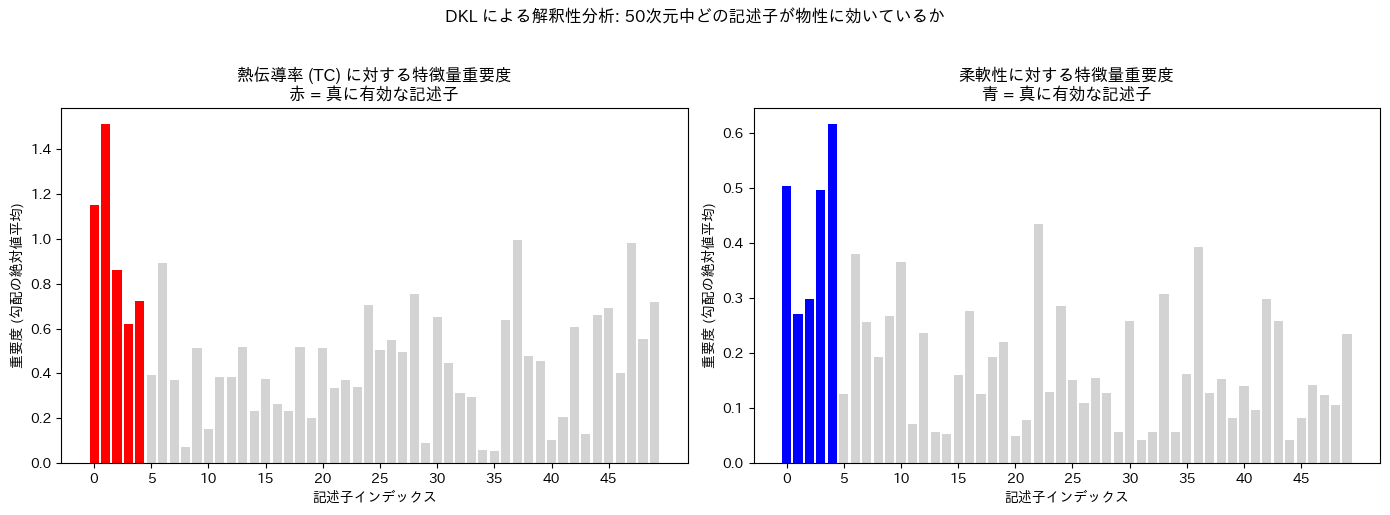

真に有効な記述子: [0, 1, 2, 3, 4]
TC の重要度 Top 5:   [1, 0, 37, 47, 6]
柔軟性の重要度 Top 5: [4, 0, 3, 22, 36]


In [15]:
# 入力感度分析: 各記述子に対する予測の勾配の大きさで重要度を推定
def compute_feature_importance(model, X, n_samples=100):
    """勾配ベースの特徴量重要度を計算"""
    model.eval()
    X_sample = X[:n_samples].clone().requires_grad_(True)

    # forward して勾配を計算
    pred = model(X_sample)
    mean = pred.mean.sum()
    mean.backward()

    # 勾配の絶対値の平均 = 各記述子の重要度
    importance = X_sample.grad.abs().mean(dim=0).detach()
    return importance

# 最後のラウンドのモデルを使用
final_models = history_al[-1]["models"]
observed_idx = history_al[-1]["observed_idx"]
X_obs = X_pool[observed_idx]

importance_tc = compute_feature_importance(final_models[0], X_obs)
importance_flex = compute_feature_importance(final_models[1], X_obs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(importance_tc))
colors_tc = ["red" if i in effective_dims else "lightgray" for i in range(len(importance_tc))]
colors_flex = ["blue" if i in effective_dims else "lightgray" for i in range(len(importance_flex))]

ax1.bar(x_pos, importance_tc.numpy(), color=colors_tc)
ax1.set_xlabel("記述子インデックス")
ax1.set_ylabel("重要度 (勾配の絶対値平均)")
ax1.set_title("熱伝導率 (TC) に対する特徴量重要度\n赤 = 真に有効な記述子")
ax1.set_xticks(range(0, 50, 5))

ax2.bar(x_pos, importance_flex.numpy(), color=colors_flex)
ax2.set_xlabel("記述子インデックス")
ax2.set_ylabel("重要度 (勾配の絶対値平均)")
ax2.set_title("柔軟性に対する特徴量重要度\n青 = 真に有効な記述子")
ax2.set_xticks(range(0, 50, 5))

plt.suptitle("DKL による解釈性分析: 50次元中どの記述子が物性に効いているか", y=1.02)
plt.tight_layout()
plt.show()

print(f"真に有効な記述子: {effective_dims}")
print(f"TC の重要度 Top 5:   {importance_tc.argsort(descending=True)[:5].tolist()}")
print(f"柔軟性の重要度 Top 5: {importance_flex.argsort(descending=True)[:5].tolist()}")

In [8]:
# 最終パレートフロント上のポリマー候補の詳細
final_idx = history_al[-1]["observed_idx"]
Y_final = Y_pool[final_idx]
pareto_mask_final = is_non_dominated(Y_final)
pareto_indices = [final_idx[i] for i, m in enumerate(pareto_mask_final) if m]
Y_pareto = Y_final[pareto_mask_final]

print("=" * 60)
print("最終パレートフロント上のポリマー候補")
print("=" * 60)
print(f"{'候補ID':>6} | {'TC':>8} | {'柔軟性':>8} | 特徴")
print("-" * 60)

# TC でソート
sort_idx = Y_pareto[:, 0].argsort(descending=True)
for i in sort_idx:
    pool_id = pareto_indices[i]
    tc = Y_pareto[i, 0].item()
    flex = Y_pareto[i, 1].item()
    if tc > Y_pareto[:, 0].median():
        note = "← TC重視"
    elif flex > Y_pareto[:, 1].median():
        note = "← 柔軟性重視"
    else:
        note = "  バランス型"
    print(f"  #{pool_id:>4d} | {tc:>8.3f} | {flex:>8.3f} | {note}")

print(f"\n→ 研究者はこのリストから目的に応じて候補を選ぶ")
print(f"  例: TC 重視なら上位、柔軟性重視なら下位、バランスなら中央")

最終パレートフロント上のポリマー候補
  候補ID |       TC |      柔軟性 | 特徴
------------------------------------------------------------
  #  35 |    2.708 |    0.257 | ← TC重視
  # 218 |    2.625 |    0.404 | ← TC重視
  # 216 |    2.467 |    0.743 | ← TC重視
  # 129 |    1.762 |    0.773 | ← TC重視
  # 174 |    1.702 |    1.064 |   バランス型
  # 441 |    1.306 |    1.150 | ← 柔軟性重視
  # 177 |    0.788 |    1.198 | ← 柔軟性重視
  # 231 |    0.762 |    1.732 | ← 柔軟性重視
  # 371 |    0.630 |    2.162 | ← 柔軟性重視

→ 研究者はこのリストから目的に応じて候補を選ぶ
  例: TC 重視なら上位、柔軟性重視なら下位、バランスなら中央


## まとめ: 全ステップの振り返り

### 論文パイプラインの対応表

| 論文のステップ | Notebook | 技術 |
|---|---|---|
| 初期データ生成 (MD) | 合成データ生成 | `generate_polymer_data` |
| DKL サロゲート × 2 | Step 3 の DKL | `DKLModel` + `ModelList` |
| MOBO (qNEHVI) | Step 2 の獲得関数 | `qLogNoisyExpectedHypervolumeImprovement` |
| AL ループ | **Step 4** | `run_al_pipeline` (離散候補プール) |
| パレートフロント特定 | `is_non_dominated` | 最終候補リスト |
| 解釈性分析 | 勾配ベース重要度 | `compute_feature_importance` |

### 学んだこと

1. **Step 1**: BO の基本（GP + EI）で少ない評価で最適値を見つける
2. **Step 2**: MOBO（GP + qNEHVI）でパレートフロントを効率的に探索
3. **Step 3**: DKL で高次元入力に対応（MLP + GP）
4. **Step 4**: AL パイプラインで全技術を統合、離散候補プールから選択

### 実データへの発展

このパイプラインの `generate_polymer_data` を実データに置き換えれば、論文と同じワークフローが回る:
- **Polymer Genome** (pgdb.org): 分子記述子つきポリマーDB
- **PolyInfo** (polymer.nims.go.jp): NIMS のポリマーDB
- 論文の supplementary data（公開されていれば）